<a id="bayesian-measurement-error-correction"></a>

# Correct measurement error

<a id="measurement-error"></a>

Repeated noisy measurements of a covariate contain information about its true
value. Fit a joint model for those measurements and the response, then inspect
how uncertainty about the latent covariate affects the regression.

This example starts afresh. It uses the model-building patterns from
{doc}`../../model-building` and the mixed-kernel workflow from
{doc}`01d-gibbs-sampling`. All dependencies are in Liesel's documentation
environment; the data are simulated below.

<a id="imports"></a>
<a id="data"></a>

## Simulate repeated measurements

For each of 80 subjects, generate a latent covariate $x_i$, three independent
measurements $w_{im}$, and one response:

$$
x_i\sim N(0,1),\qquad
w_{im}\mid x_i\sim N(x_i,0.6^2),\qquad
y_i\mid x_i\sim N(1+2x_i,0.5^2).
$$

Here and below, the second argument of $N$ in equations is a **variance**.
TFP's `Normal(scale=...)` instead takes a **standard deviation**.

In [1]:
import jax
import jax.numpy as jnp
import pandas as pd
import plotnine as p9
import tensorflow_probability.substrates.jax.bijectors as tfb
import tensorflow_probability.substrates.jax.distributions as tfd

import liesel.goose as gs
import liesel.model as lsl

n, replicates = 80, 3
x_key, w_key, y_key = jax.random.split(jax.random.key(123), 3)
x_true = jax.random.normal(x_key, (n,))
w_data = x_true[:, None] + 0.6 * jax.random.normal(w_key, (n, replicates))
y_data = 1.0 + 2.0 * x_true + 0.5 * jax.random.normal(y_key, (n,))

observed = pd.DataFrame({"mean_measurement": w_data.mean(axis=1), "y": y_data})

<a id="plot-data"></a>

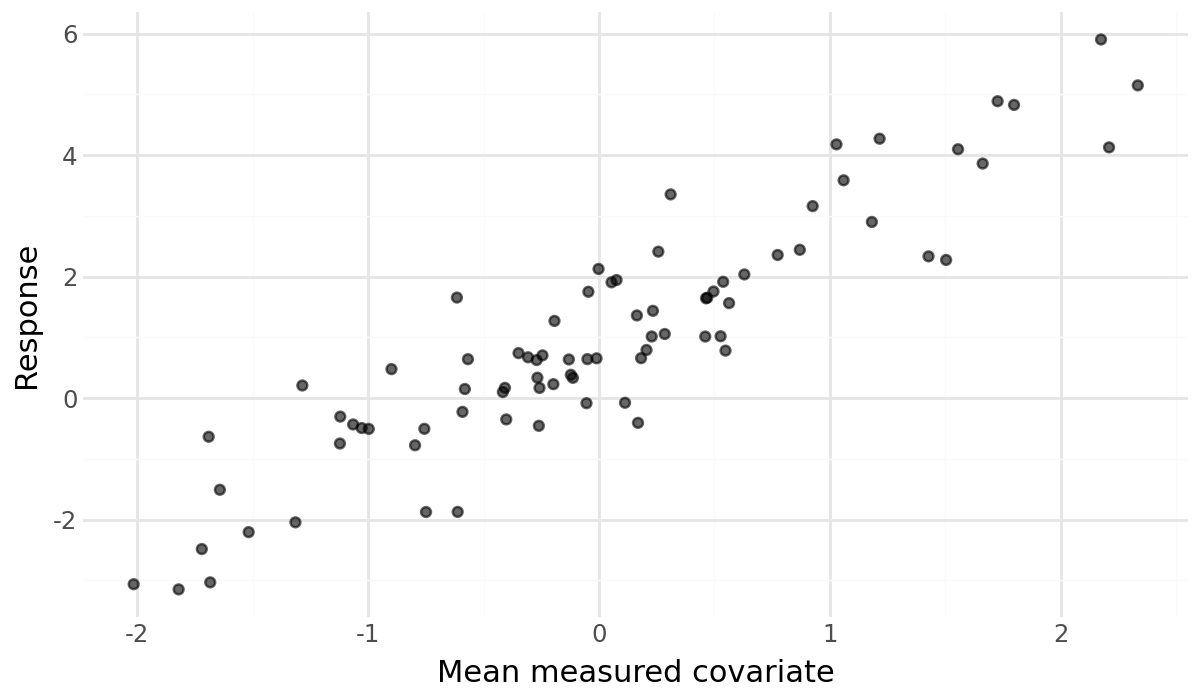

In [2]:
(
    p9.ggplot(observed, p9.aes("mean_measurement", "y"))
    + p9.geom_point(alpha=0.6)
    + p9.labs(x="Mean measured covariate", y="Response")
    + p9.theme_minimal()
    + p9.theme(figure_size=(6, 3.5))
).show()

A regression on these averages would treat them as error-free. Their measurement
error is smaller than that of a single replicate, but remains present and can
attenuate the estimated slope. We model it explicitly instead.

<a id="implementing-the-model-in-liesel"></a>

## Define the joint model

Use a hierarchical prior for the latent covariate and proper, moderately
regularizing priors on the scales:

$$
\begin{aligned}
x_i\mid\mu_x,\tau_x^2 &\sim N(\mu_x,\tau_x^2), &
\mu_x &\sim N(0,4), & \tau_x^2 &\sim IG(3,2),\\
\beta_j &\sim N(0,2.5^2), &
\sigma_y^2 &\sim IG(3,0.5), & \sigma_u^2 &\sim IG(3,0.72).
\end{aligned}
$$

`IG(a, b)` has density proportional to $v^{-a-1}\exp(-b/v)$ for $v>0$.
These priors are choices for the standardized simulated data, not generally
uninformative defaults. The replicate errors are independent conditional on
$x_i$ and share a common variance. The response is conditional on latent `x`,
not on its noisy measurements.

In [3]:
# Latent covariate distribution
mu_x = lsl.Var.new_param(
    0.0,
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.0),
    name="mu_x",
)

tau2_x = lsl.Var.new_param(
    1.0,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=2.0),
    name="tau2_x",
)
tau_x = lsl.Var.new_calc(jnp.sqrt, tau2_x, name="tau_x")

x = lsl.Var.new_param(
    w_data.mean(axis=1),
    dist=lsl.Dist(tfd.Normal, loc=mu_x, scale=tau_x),
    name="x",
)

# Regression and noise parameters
beta = lsl.Var.new_param(
    jnp.array([0.0, 1.0]),
    dist=lsl.Dist(tfd.Normal, loc=0.0, scale=2.5),
    name="beta",
)

sigma2_y = lsl.Var.new_param(
    0.5,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=0.5),
    name="sigma2_y",
)
sigma_y = lsl.Var.new_calc(jnp.sqrt, sigma2_y, name="sigma_y")

sigma2_u = lsl.Var.new_param(
    0.5,
    dist=lsl.Dist(tfd.InverseGamma, concentration=3.0, scale=0.72),
    name="sigma2_u",
)
sigma_u = lsl.Var.new_calc(jnp.sqrt, sigma2_u, name="sigma_u")

# Two observation processes share the latent x.
mu_y = lsl.Var.new_calc(
    lambda x, b: b[0] + b[1] * x,
    x,
    beta,
    name="mu_y",
)
y = lsl.Var.new_obs(
    y_data,
    dist=lsl.Dist(tfd.Normal, loc=mu_y, scale=sigma_y),
    name="y",
)

measurement_mean = lsl.Var.new_calc(lambda x: x[:, None], x, name="measurement_mean")
w = lsl.Var.new_obs(
    w_data,
    dist=lsl.Dist(tfd.Normal, loc=measurement_mean, scale=sigma_u),
    name="w",
)

sigma2_y.biject(tfb.Exp(), name="log_sigma2_y")
sigma2_u.biject(tfb.Exp(), name="log_sigma2_u")
model = lsl.Model([y, w])
interface = gs.LieselInterface(model)

<a id="plot-vars"></a>

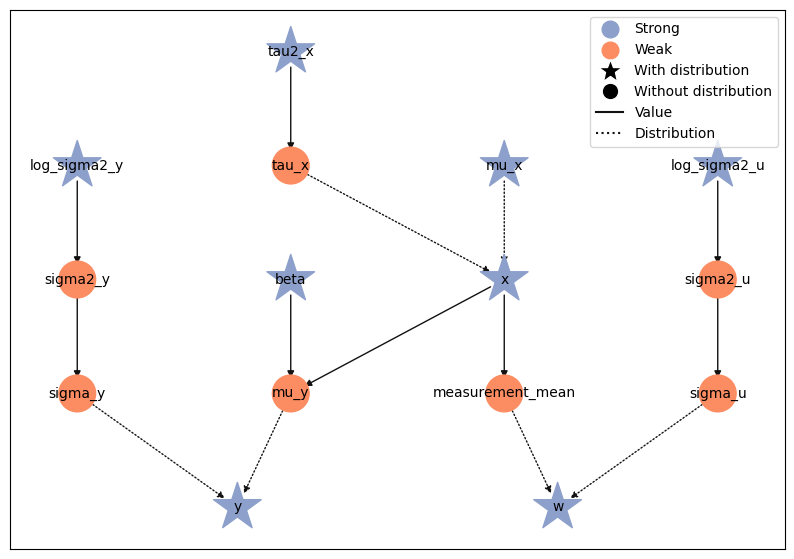

In [4]:
model.plot(width=10, height=7)

Both `y` and `w` are observed roots. Their densities contribute to the likelihood;
the latent `x` density contributes to the prior. Fixed hyperparameters are numeric
constants, not parameters. Every normal distribution receives a standard
deviation, obtained by taking a square root where we place a prior on variance.
The exponential bijections preserve the noise-variance priors and include their
Jacobians in the transformed density.

## Use the full conditionals

Conditional on the current latent covariates, the hyperparameters have simple
updates:

$$
\begin{aligned}
V_\mu &= (1/4+n/\tau_x^2)^{-1}, &
m_\mu &= V_\mu\sum_i x_i/\tau_x^2,\\
\mu_x\mid\cdot &\sim N(m_\mu,V_\mu), &
\tau_x^2\mid\cdot &\sim IG\left(3+n/2,\;2+\tfrac12\sum_i(x_i-\mu_x)^2\right).
\end{aligned}
$$

The hyperparameter constants below match the priors above. Read changing values
from the supplied `model_state`, so each update conditions on the preceding
updates in the same iteration.

In [5]:
def mu_x_conditional(model_state):
    pos = interface.extract_position(["x", "tau2_x"], model_state)
    variance = 1.0 / (1.0 / 4.0 + pos["x"].size / pos["tau2_x"])
    mean = variance * pos["x"].sum() / pos["tau2_x"]
    return tfd.Normal(loc=mean, scale=jnp.sqrt(variance))


def tau2_x_conditional(model_state):
    pos = interface.extract_position(["x", "mu_x"], model_state)
    return tfd.InverseGamma(
        concentration=3.0 + pos["x"].size / 2,
        scale=2.0 + jnp.sum((pos["x"] - pos["mu_x"]) ** 2) / 2,
    )


def draw_mu_x(prng_key, model_state):
    return {"mu_x": mu_x_conditional(model_state).sample(seed=prng_key)}


def draw_tau2_x(prng_key, model_state):
    return {"tau2_x": tau2_x_conditional(model_state).sample(seed=prng_key)}

Use one NUTS block for the regression coefficients, latent covariates, and
transformed noise variances. Follow it with the two exact Gibbs updates.
This grouping helps NUTS move along dependencies between the slope and latent
covariates; other groupings should be checked with diagnostics.

In [6]:
joint = gs.MCMCSpec(
    gs.NUTSKernel,
    kernel_group="regression",
    kernel_kwargs={"da_target_accept": 0.9},
    jitter_dist=tfd.Normal(0.0, 0.1),
    order=1,
)
for name in ["beta", "x", "log_sigma2_y", "log_sigma2_u"]:
    model.vars[name].inference = joint

model.vars["mu_x"].inference = gs.MCMCSpec(
    gs.GibbsKernel.with_transition_fn(draw_mu_x),
    jitter_dist=tfd.Normal(0.0, 0.1),
    order=2,
)
model.vars["tau2_x"].inference = gs.MCMCSpec(
    gs.GibbsKernel.with_transition_fn(draw_tau2_x),
    jitter_dist=tfd.LogNormal(0.0, 0.1),
    jitter_method="multiplicative",
    order=3,
)

<a id="mcmc-inference"></a>

## Fit and inspect

In [7]:
results = gs.LieselMCMC(model).run_for_epochs(
    seed=19,
    num_chains=4,
    adaptation=1000,
    posterior=2000,
    show_progress=False,
)
samples = results.get_posterior_samples()
summary = gs.Summary(results)
parameter_summary = gs.Summary(results, deselected=["x"])

liesel.goose.engine - INFO - Initializing kernels...


liesel.goose.engine - INFO - Done


liesel.goose.engine - INFO - Finished warmup


<a id="plot-param-mu-x"></a>

In [8]:
parameter_summary.to_dataframe().set_index("var_fqn")[
    ["mean", "sd", "q_0.05", "q_0.95", "rhat", "ess_bulk"]
].round(3)

,mean,sd,q_0.05,q_0.95,rhat,ess_bulk
var_fqn,,,,,,
beta[0],0.959,0.093,0.807,1.113,1.002,2636.504
beta[1],2.069,0.111,1.888,2.256,1.003,1468.416
log_sigma2_u,-0.996,0.101,-1.160,-0.826,1.000,4261.352
log_sigma2_y,-1.794,0.412,-2.483,-1.123,1.004,547.084
mu_x,0.003,0.110,-0.177,0.182,1.000,4960.181
tau2_x,0.852,0.153,0.629,1.128,1.001,3344.338


In [9]:
summary.aggregate_diagnostics().round(3)

,ess_bulk,ess_tail,rhat,aggregated_by
parameter,,,,
beta,1468.416,2541.719,1.003,min (ess); max (rhat)
log_sigma2_u,4261.352,5689.260,1.000,min (ess); max (rhat)
log_sigma2_y,547.084,909.889,1.004,min (ess); max (rhat)
mu_x,4960.181,6527.851,1.000,min (ess); max (rhat)
tau2_x,3344.338,5288.676,1.001,min (ess); max (rhat)
x,1821.998,2746.043,1.002,min (ess); max (rhat)


In [10]:
summary.error_df().reset_index().filter(["error_msg", "phase", "count"])

,error_msg,phase,count
0,divergent transition,warmup,27
1,divergent transition,posterior,0


The first table excludes the 80 latent covariates for readability; the aggregate
diagnostics include them. Check chain agreement, effective sample sizes, and
posterior sampler errors before interpreting either global parameters or
individual covariates. In this run the coefficient intervals include the
generating values, chain agreement is close to one, and there are no posterior
divergences. The response-noise variance has the lowest effective sample size;
its uncertainty is less precisely estimated than the other global quantities.
The warmup divergences remain visible in the error table. The `log_sigma2_*`
entries are log **variances**, not standard deviations.

<a id="plot-trace-mean"></a>
<a id="plot-sigma-y"></a>
<a id="plot-sigma-x"></a>

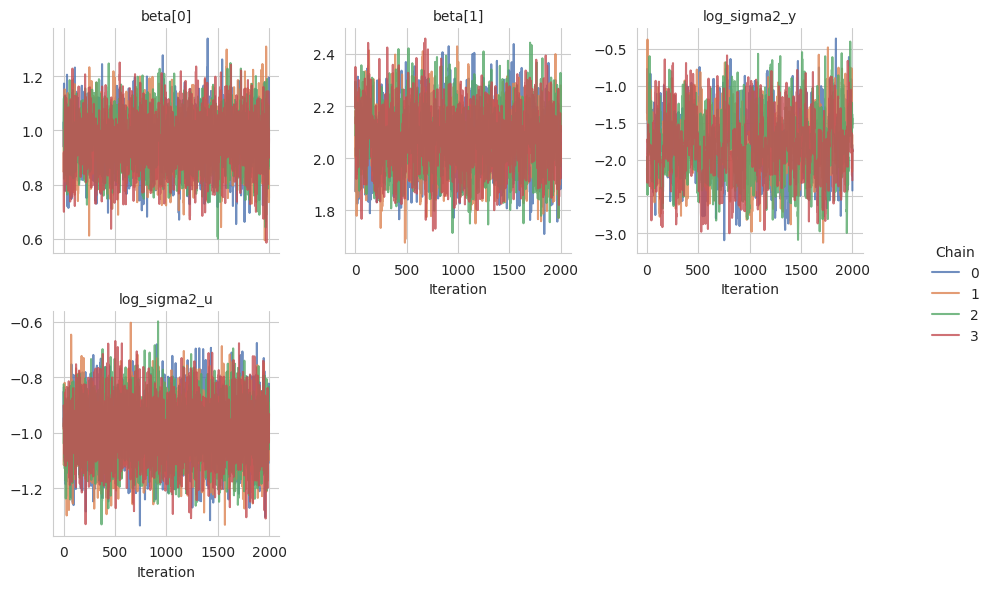

In [11]:
gs.plot_trace(results, params=["beta", "log_sigma2_y", "log_sigma2_u"])

## Inspect the correction

For simulated data, we can compare the latent estimates with their known true
values. This comparison is unavailable in an ordinary observed dataset.

In [12]:
x_summary = gs.SamplesSummary(
    {"x": samples["x"]},
    quantiles=(0.05, 0.5, 0.95),
    which=["quantiles"],
)
x_q = x_summary.quantities["quantile"]["x"]
latent = pd.DataFrame(
    {
        "truth": x_true,
        "measured": w_data.mean(axis=1),
        "lower": x_q[0],
        "median": x_q[1],
        "upper": x_q[2],
    }
)

<a id="plot-trace-x"></a>

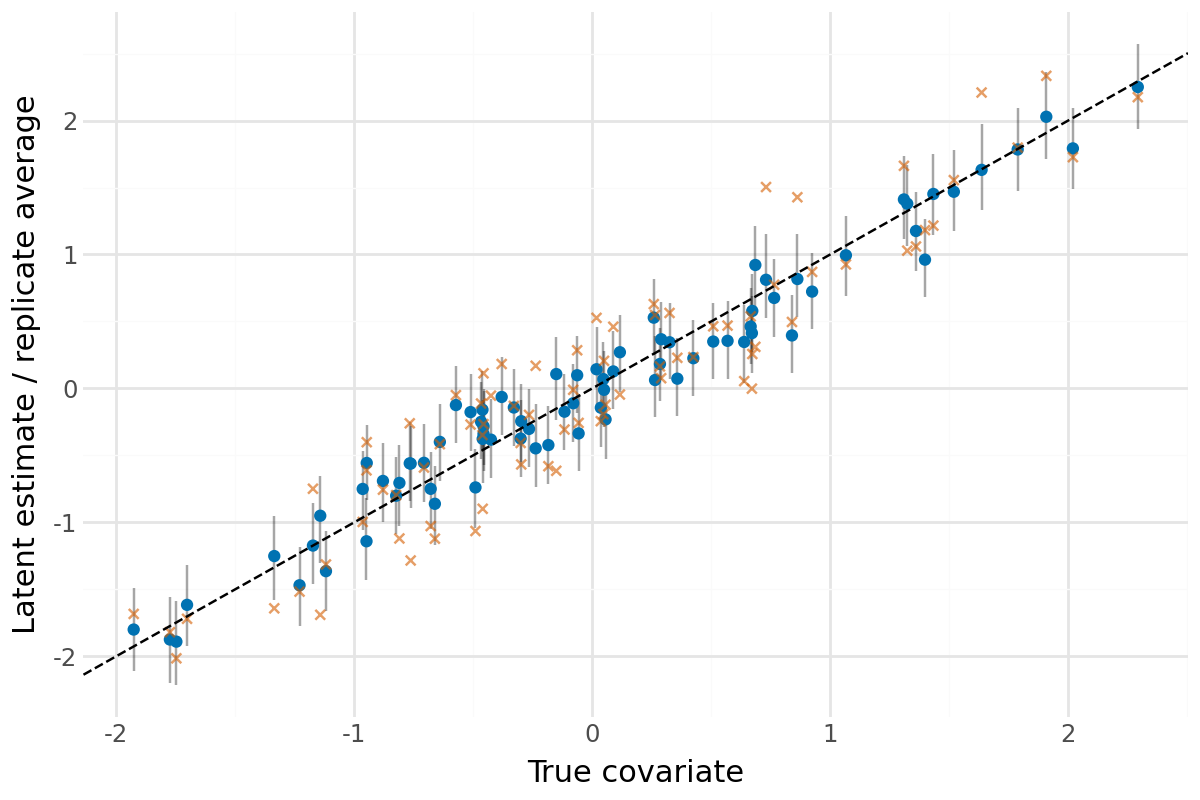

In [13]:
(
    p9.ggplot(latent, p9.aes("truth", "median"))
    + p9.geom_linerange(p9.aes(ymin="lower", ymax="upper"), alpha=0.35)
    + p9.geom_point(color="#0072B2", size=1.5)
    + p9.geom_point(p9.aes(y="measured"), color="#D55E00", shape="x", alpha=0.6)
    + p9.geom_abline(slope=1.0, intercept=0.0, linetype="dashed")
    + p9.labs(x="True covariate", y="Latent estimate / replicate average")
    + p9.theme_minimal()
    + p9.theme(figure_size=(6, 4))
).show()

The model uses both measurements and the response to estimate each covariate.
The intervals express posterior uncertainty; the correction need not move every
subject closer to its true value. Assess the measurement model and prior
sensitivity before applying this interpretation to real data.

To summarize the regression relationship, evaluate it at each posterior draw.
Do not multiply separate posterior means of dependent quantities. Supply only
the coefficient draws here: the grid replaces latent `x`, so its fitted draws
must not also appear in `samples`.

In [14]:
x_grid = jnp.linspace(-2.5, 2.5, 60)
mean_draws = model.predict(
    {"beta": samples["beta"]},
    predict=["mu_y"],
    newdata={"x": x_grid},
)
curve_summary = gs.SamplesSummary(
    mean_draws,
    quantiles=(0.05, 0.5, 0.95),
    which=["quantiles"],
)
curve_q = curve_summary.quantities["quantile"]["mu_y"]
curve = pd.DataFrame(
    {"x": x_grid, "lower": curve_q[0], "median": curve_q[1], "upper": curve_q[2]}
)

<a id="plot-regression-line"></a>

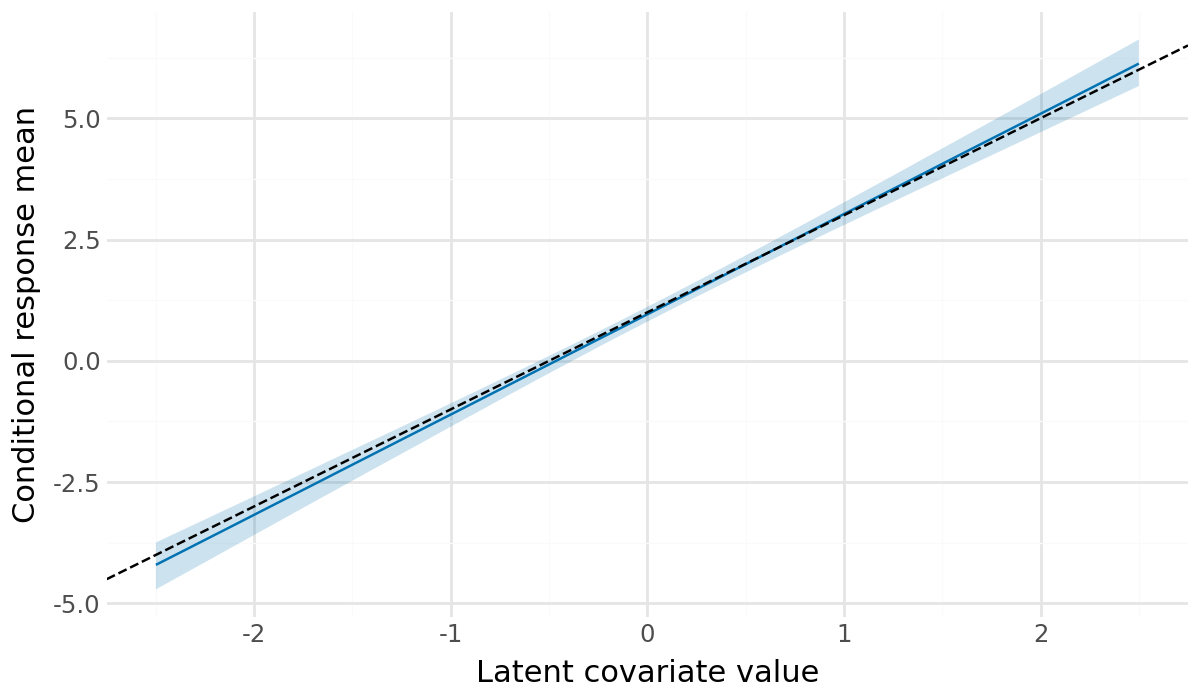

In [15]:
(
    p9.ggplot(curve, p9.aes("x", "median"))
    + p9.geom_ribbon(p9.aes(ymin="lower", ymax="upper"), fill="#0072B2", alpha=0.2)
    + p9.geom_line(color="#0072B2")
    + p9.geom_abline(slope=2.0, intercept=1.0, linetype="dashed")
    + p9.labs(x="Latent covariate value", y="Conditional response mean")
    + p9.theme_minimal()
    + p9.theme(figure_size=(6, 3.5))
).show()

This curve conditions on a chosen *true* covariate value. It is not a prediction
given a future noisy measurement; that requires integrating over the future
latent covariate as well. Its band describes uncertainty in the mean and excludes
new response noise. See {doc}`../../model-prediction` and
{doc}`../../model-simulation` for those distinctions.